In [1]:
from dpk_docling2parquet import Docling2Parquet
from data_processing.utils import GB
from dpk_docling2parquet.transform import docling2parquet_contents_types

In [2]:
%%capture
x=Docling2Parquet(input_folder= "test-data/granite_docling_input", 
               output_folder= "output", 
               data_files_to_use=['.pdf','.zip','.xml'],          
               docling2parquet_contents_type=docling2parquet_contents_types.JSON,
               docling2parquet_generate_picture_images=True,
               #docling2parquet_generate_page_images=True,
               docling2parquet_pipeline="vlm").transform()

14:17:57 INFO - docling2parquet parameters are : {'batch_size': -1, 'artifacts_path': None, 'contents_type': <docling2parquet_contents_types.JSON: 'application/json'>, 'do_table_structure': True, 'do_ocr': True, 'ocr_engine': <docling2parquet_ocr_engine.EASYOCR: 'easyocr'>, 'bitmap_area_threshold': 0.05, 'pdf_backend': <docling2parquet_pdf_backend.DLPARSE_V2: 'dlparse_v2'>, 'double_precision': 8, 'pipeline': <docling2parquet_pipeline.VLM: 'vlm'>, 'generate_picture_images': True, 'generate_page_images': False, 'images_scale': 2.0}
2025-10-23 14:17:57,762 - INFO - docling2parquet parameters are : {'batch_size': -1, 'artifacts_path': None, 'contents_type': <docling2parquet_contents_types.JSON: 'application/json'>, 'do_table_structure': True, 'do_ocr': True, 'ocr_engine': <docling2parquet_ocr_engine.EASYOCR: 'easyocr'>, 'bitmap_area_threshold': 0.05, 'pdf_backend': <docling2parquet_pdf_backend.DLPARSE_V2: 'dlparse_v2'>, 'double_precision': 8, 'pipeline': <docling2parquet_pipeline.VLM: 'vlm

In [3]:
import pyarrow.parquet as pq
import pandas as pd
table = pq.read_table('output/granite-docling.parquet')

In [4]:
table.to_pandas()

,filename,contents,num_pages,num_tables,num_doc_elements,document_id,document_hash,ext,hash,size,date_acquired,document_convert_time,image_bins,orig_image_fpaths,num_pictures,source_filename
0,granite-docling.pdf,"{""schema_name"":""DoclingDocument"",""version"":""1....",8,1,140,98787987-f1b2-45c7-8861-9f4993f93d55,f555f6260be1de6cd8f75addca4edc3c4456b2d5f3bf01...,pdf,e67c87e093718b6fe8894867be10f1491f02e4e1fdb9d2...,3681065,2025-10-23T14:19:49.992223,112.195314,[b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00...,[/var/folders/lv/zfkvk5n1563d6d48l2vqqrs00000g...,7,granite-docling.pdf


In [5]:
table.to_pandas()['contents'][0]

'{"schema_name":"DoclingDocument","version":"1.7.0","name":"Document","furniture":{"self_ref":"#\\/furniture","children":[],"content_layer":"furniture","name":"_root_","label":"unspecified"},"body":{"self_ref":"#\\/body","children":[{"$ref":"#\\/texts\\/0"},{"$ref":"#\\/texts\\/1"},{"$ref":"#\\/texts\\/2"},{"$ref":"#\\/texts\\/3"},{"$ref":"#\\/texts\\/4"},{"$ref":"#\\/texts\\/5"},{"$ref":"#\\/texts\\/6"},{"$ref":"#\\/texts\\/7"},{"$ref":"#\\/texts\\/8"},{"$ref":"#\\/texts\\/9"},{"$ref":"#\\/texts\\/10"},{"$ref":"#\\/texts\\/11"},{"$ref":"#\\/texts\\/12"},{"$ref":"#\\/texts\\/13"},{"$ref":"#\\/groups\\/0"},{"$ref":"#\\/texts\\/20"},{"$ref":"#\\/texts\\/21"},{"$ref":"#\\/texts\\/22"},{"$ref":"#\\/pictures\\/0"},{"$ref":"#\\/texts\\/23"},{"$ref":"#\\/texts\\/24"},{"$ref":"#\\/texts\\/25"},{"$ref":"#\\/texts\\/26"},{"$ref":"#\\/texts\\/27"},{"$ref":"#\\/texts\\/28"},{"$ref":"#\\/texts\\/29"},{"$ref":"#\\/texts\\/30"},{"$ref":"#\\/texts\\/31"},{"$ref":"#\\/texts\\/32"},{"$ref":"#\\/groups\\

In [6]:
table.to_pandas()['image_bins'][0]

array([b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01\xa5\x00\x00\x00\xc6\x08\x02\x00\x00\x00\xfd\xa7\x08\xb9\x00\x00\xaa[IDATx\x9c\xec]\x05|\x1dU\xf6\xbew\xec\xb9D^\xdc]\x9a6u\xf7RA\x0b-R\x8a\xbb-,,\xb2\xc8\xe2\xbb\xd8.\xfc\x17v\xb1\x05\x96\xc5\x8b\x16\nmi)\xd4\xa8k\xd24\xeen/\xcfe\xe4\xde\xff\xef\xce\xa4!\xb4I\x9a\xa4I\xa0\xf0>\xfa\x0b\xef\xbd\x997s\xdf\xc8\x99s\xcf\xf9\xcew \xc6\x18\x8c\x08\xb0hG\x9e\n\x00\xa9\x91\xd9]\x00\x01\x9c.\x80\x00\xf3\x94\xdaC\x1b!\x18\xa1\x9bq\xd0\xa0 \xa8\xf1R\x08Z(\x08\xc1i\x05\x84A\x82\x96\nX\x9f\x00\x02\x08\xe0\xf7\x02\xe6\x17\xdd;\x84\x90\x02\x10\x00\x8c1F\xe4\x1d \xf6\x17\x03\x04d\xafS^*?F\x94\x15~\xf6\x15\x841\x86\x90\xc2\x00++\xf7\xb6\x03y!\x86\x90\x96\xb7\xf0k\x7f~\x06\x10@\x00\xbfI{\x071\x16\x05\x9f\x13I\x02\xa32\xb0\x9cA\xe4]\x02\xef\x02\x00p\x9a \x8a\xe60\x12\x05\xde%\xf1nb\xadh\x8eU\x19\x89uC\x02\xefw`$\xb1j3\xcd\xaa\xfd\xee6\x9a\xd5\xd0\xac\xa67\x93\'\n^H1\x10R~O\x1b\xab6S\x14\x1b0y\x01\x04\xf0\xbb\xc5/f\xef(\x8avZ\xab*\x0e\xbc\xc5\xaa\xcd

In [7]:
import io
from IPython.display import display
import PIL.Image as Image

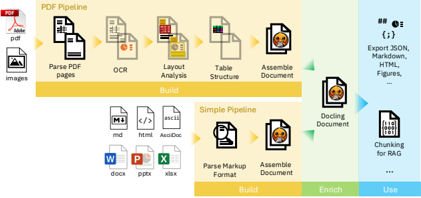

In [9]:
df = table.to_pandas()
image = Image.open(io.BytesIO(df.iloc[0]['image_bins'][0]))
display(image)